# Evaluation of the implemented RAG-CBR System for second-level natural language xAI graph explanations generation

## Introduction

This notebook will be the culmination of this project, executing the evaluation of the implemented RAG-CBR system for generating second-level natural language xAI graph explanations. In order to do so, we will be following a **Leave-One-Out** approach over all the cases generated for the seed case base. The process will be guided by the presented roadmap:
1. Previously, we batch generated on Kaggle an output insight for every case using the **complete retrieval system** and the **few-shot prompt technique**. The LLM used for this task was **Pixtral-12B**, as it showed the best performance during the *Temperature Experiment* we ran. The final system is prepared to use all 3 LLMs + the hallucination detection and summarization module on input, but for computational limitations the evaluation was done using only one. However, the seed case generation (using hallucination detection and summarization modules) combined with the retrieval and few-shot prompt should already mitigate the hallucination effects of the final results.
2. After that, we used the `generate_emeddings.py` script to generate embeddings for every image and produced text using the new Gemini Embedding 2 (available for free use with certain quota limits on the Google API). This choice was perfect for the task, as it is a multimodal embedding model, which means it can map text, images, videos, audio, and PDFs to a unified embedding space, allowing us to compare every text embedding to the image embedding. The list of generated embeddings is:
    - **Images**
    - **Qwen Insights (Zero-shot)**
    - **Pixtral Insights (Zero-shot)**
    - **Idefics Insights (Zero-shot)**
    - **Summarized Insights (Zero-shot)**
    - **RAG Solution Insights (Few-shot Pixtral with retrieved cases)**
3. Now, we will use **Cosine Similarity** to calculate the similarity score between every text embedding and the corresponding image embedding.
4. The next step will be using the similarity scores for different **Mathematical Aggregations** in order to analyze the performance of the 4 baseline texts (Qwen, Pixtral, Idefics and the Summarized Insights with zero-shot prompts) against the RAG Solution Insights.
5. To conclude, we will capture the obtained results and draw our final conclusions based on them.

## Section 0: Setup & Configuration

In this section we will run the code for required imports and establish the paths we will be using across the project directories.

In [18]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Path Configuration
SRC_DIR = os.getcwd()                       # ../evaluation/src
EVAL_ROOT = os.path.dirname(SRC_DIR)        # ../evaluation
PROJECT_ROOT = os.path.dirname(EVAL_ROOT)   # ../
XAI_RAG_DIR = os.path.join(PROJECT_ROOT, "xai_rag_cbr")
CASE_BASE_CSV = os.path.join(XAI_RAG_DIR, "data", "processed", "case_base.csv")
EMBEDDINGS_DIR = os.path.join(EVAL_ROOT, "data", "embeddings")
PROCESSED_DATA_DIR = os.path.join(EVAL_ROOT, "data", "processed")
SCORES_CSV = os.path.join(PROCESSED_DATA_DIR, "similarity_scores.csv")

# Embeddings sub-directories names
MODELS = ["qwen", "pixtral", "idefics", "summary", "rag_solution"]

## Section 1: Calculating Cosine Similarity Scores with the generated Embeddings

In this section we will iterate through the case base, load the generated embeddings (`.npy` vectors) for the image and the 5 corresponding text outputs (4 baselines, 1 final output to evaluate), and calculate the similarity between them using **cosine similarity score**.

The used formula for the cosine similarity of vectors $A$ (Image) and $B$ (Text) is:
$$Cosine\ Similarity = \frac{A \cdot B}{||A|| ||B||}$$

We will then attach these scores to certain metadata columns (`analytical_family`, `library`, `xai_graph_type`, `ai_problem_type`, `scope`) to prepare the date for the final stratified analysis, and save the result into a CSV file (`similarity_scores.csv`).

In [19]:
# Cosine-Similairty auxiliar function
def compute_cosine_similarity(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """Calculates the cosine similarity between two vectors."""
    if vec_a is None or vec_b is None:
        return np.nan
    return np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))

# Load the case base to iterate over
df_metadata = pd.read_csv(CASE_BASE_CSV, dtype={'id': str})
df_metadata['id'] = df_metadata['id'].str.zfill(6)

# Only keep the relevant columns for the stratified analysis
columns_to_keep = ['id', 'library', 'xai_graph_type', 'analytical_family', 'ai_problem_type', 'scope']
df_scores = df_metadata[columns_to_keep].copy()

# Empty lists to store the scores
score_lists = {model: [] for model in MODELS}

# Iterate through cases and calculate metrics
for case_id in tqdm(df_scores['id'], desc="Processing Cases"):
    
    # Load Image Vector
    img_path = os.path.join(EMBEDDINGS_DIR, "images", f"{case_id}.npy")
    try:
        vec_img = np.load(img_path)
    except FileNotFoundError:
        # If an embedding failed to generate, we append NaN to keep dataframe aligned
        for model in MODELS: score_lists[model].append(np.nan)
        continue

    # Load Text Vectors and Compute Scores
    for model in MODELS:
        txt_path = os.path.join(EMBEDDINGS_DIR, model, f"{case_id}.npy")
        try:
            vec_txt = np.load(txt_path)
            score = compute_cosine_similarity(vec_img, vec_txt)
            score_lists[model].append(score)
        except FileNotFoundError:
            score_lists[model].append(np.nan)

# Add the calculated scores as new columns fore each case
for model in MODELS:
    df_scores[f"{model}_score"] = score_lists[model]

# Save to the CSV file for later analysis
df_scores.to_csv(SCORES_CSV, index=False)

df_scores.head()

Processing Cases:   0%|          | 0/1382 [00:00<?, ?it/s]

,id,library,xai_graph_type,analytical_family,ai_problem_type,scope,qwen_score,pixtral_score,idefics_score,summary_score,rag_solution_score
0,000001,SHAP,Waterfall,Local_Attribution,Regression,Local,0.742369,0.735295,0.729529,0.758156,0.751655
1,000002,SHAP,Force,Local_Attribution,Regression,Local,0.739119,0.684594,0.692176,0.721447,0.706747
2,000003,SHAP,Bar,Local_Attribution,Regression,Local,0.733952,0.748147,0.754011,0.731100,0.735751
3,000004,SHAP,Bar,Cohort_Pattern,Regression,Cohort,0.749408,0.696704,0.651690,0.733477,0.720638
4,000005,SHAP,Bar,Global_Summary,Regression,Global,0.737824,0.735778,0.744324,0.716299,0.736236


## Section 2: Statistical Analysis & Comparative Performance

In this section, we will mathematically aggregate the cosine similarity scores produced in the prvious section to evaluate the performance of the RAG system against the baselines. The analysis is divided into two parts:
1. **Global Descriptive Statistics:** Analyzing the overall Mean, Median, and Standard Deviation (stability) of all generation approaches. We also calculate the % win rate (cases where each model obtained the best score out of the 5) for each model.
2. **Comparative Testing:** Measuring the direct performance of the `rag_solution` against each zero-shot baseline using:
    * **Win Rate:** The percentage of cases where the RAG score strictly exceeded the baseline score.
    * **Delta ($\Delta$):** The average numerical improvement provided by the RAG system.
    * **Usability Thresholding:** Defining a 'High Quality' benchmark (e.g., Cosine Similarity $\ge 0.85$) and measuring what percentage of cases for each model cross this threshold.
    * **Statistical Significance (Wilcoxon Signed-Rank Test):** A non-parametric test ($p < 0.05$) to mathematically prove the improvements are systematic rather than random chance.

In [20]:
print("--- 1. GLOBAL DESCRIPTIVE STATISTICS ---")

# Calculate the percentage of times each model is the absolute best
score_cols = [f"{m}_score" for m in MODELS]
best_model_counts = df_scores[score_cols].idxmax(axis=1).value_counts(normalize=True) * 100

stats_data = []
for model in MODELS:
    col = f"{model}_score"
    stats_data.append({
        "Model": model.upper(),
        "Mean Score": df_scores[col].mean(),
        "Median Score": df_scores[col].median(),
        "Std Dev (Stability)": df_scores[col].std(),
        "Max Score": df_scores[col].max(),
        "Min Score": df_scores[col].min(),
        "Best Model Rate (%)": best_model_counts.get(col, 0.0) 
    })

df_global_stats = pd.DataFrame(stats_data).round(4)
display(df_global_stats)

--- 1. GLOBAL DESCRIPTIVE STATISTICS ---


,Model,Mean Score,Median Score,Std Dev (Stability),Max Score,Min Score,Best Model Rate (%)
0,QWEN,0.7413,0.7442,0.0264,0.8061,0.6443,52.1708
1,PIXTRAL,0.7272,0.7293,0.0269,0.7923,0.6215,14.7612
2,IDEFICS,0.7090,0.7113,0.0319,0.7911,0.6027,7.0912
3,SUMMARY,0.7204,0.7232,0.0304,0.7941,0.6083,5.1375
4,RAG_SOLUTION,0.7315,0.7339,0.0250,0.7962,0.5918,20.8394


In the introduction text for this section, we mentioned $0.85$ as the theoretical example for the **High Quality Threshold** used in Usablity Thresholding. However, because we are testing a novel functionallity (such as using `gemini-embedding-2`, a general purpose multimodal embedding modal, to perform cross-modal semantic comparisons between text and raw images), the boundaries of this specific vector space were previously unknown.

Therefore, analyzing the global descriptive statistics is a great benchmark to adjust the **High Quality Threshold** value. We can observe that the maximum similarity score achieved by any model across the entire dataset was approximately $0.80$, which means that using the initial $0.85$ would be mathematically incompatible (0% usability rate across all baselines) with this vector space. 

Consequently, to establish a rigorous but mathematically realistic benchmark, we modified the threshold to **$0.75$**. This updated value sits strictly above the median performance of the leading models, ensuring it accurately isolates only the highest-quality, above-average generations.

In [21]:
print("\n--- 2. COMPARATIVE TESTING (RAG vs BASELINES) ---")

USABILITY_THRESHOLD = 0.75

baselines = [m for m in MODELS if m != "rag_solution"]
rag_col = "rag_solution_score"

comparative_data = []

for baseline in baselines:

    base_col = f"{baseline}_score"
    
    # Drop rows with NaN in either column to ensure fair math
    valid_mask = df_scores[rag_col].notna() & df_scores[base_col].notna()
    rag_valid = df_scores.loc[valid_mask, rag_col]
    base_valid = df_scores.loc[valid_mask, base_col]
    
    # Calculate Win Rate
    wins = (rag_valid > base_valid).sum()
    total_valid = len(rag_valid)
    win_rate = (wins / total_valid) * 100 if total_valid > 0 else 0
    
    # Calculate Mean Improvement (Delta)
    mean_delta = (rag_valid - base_valid).mean()

    # Usability Thresholding
    rag_usable = (rag_valid >= USABILITY_THRESHOLD).sum()
    base_usable = (base_valid >= USABILITY_THRESHOLD).sum()
    rag_pass_rate = (rag_usable / total_valid) * 100 if total_valid > 0 else 0
    base_pass_rate = (base_usable / total_valid) * 100 if total_valid > 0 else 0
    
    # Wilcoxon Signed-Rank Test (using 'greater' alternative hypothesis: RAG is greater than Baseline)
    try:
        statistic, p_value = stats.wilcoxon(rag_valid, base_valid, alternative='greater')
        is_significant = "Yes" if p_value < 0.05 else "No"
    except ValueError:
        # Handles edge cases where all differences are zero
        p_value = np.nan
        is_significant = "N/A"

    comparative_data.append({
        "Baseline": baseline.upper(),
        "RAG Win Rate (%)": f"{win_rate:.2f}%",
        "Mean Improvement (Delta \u0394)": f"+{mean_delta:.4f}" if mean_delta > 0 else f"{mean_delta:.4f}",
        f"Baseline Usability (>{USABILITY_THRESHOLD})": f"{base_pass_rate:.1f}%",
        f"RAG Usability (>{USABILITY_THRESHOLD})": f"{rag_pass_rate:.1f}%",
        "Wilcoxon p-value": f"{p_value:.4e}" if pd.notna(p_value) else "NaN",
        "Statistically Significant? (p<0.05)": is_significant
    })

df_comparative = pd.DataFrame(comparative_data)
display(df_comparative)


--- 2. COMPARATIVE TESTING (RAG vs BASELINES) ---


,Baseline,RAG Win Rate (%),Mean Improvement (Delta Δ),Baseline Usability (>0.75),RAG Usability (>0.75),Wilcoxon p-value,Statistically Significant? (p<0.05)
0,QWEN,31.40%,-0.0098,41.9%,24.6%,1.0000e+00,No
1,PIXTRAL,58.03%,+0.0043,19.3%,24.6%,3.9233e-14,Yes
2,IDEFICS,80.25%,+0.0225,9.0%,24.6%,2.8859e-132,Yes
3,SUMMARY,67.73%,+0.0111,15.8%,24.6%,2.4086e-54,Yes


To help us translate the statistical metrics we just calculated into conclusions, we use six different charts. Each one highlights a different part of how the system performed:

* **1. Global Distribution (Violin Plot):** This illustrates the stability of the models. While mean scores can be affected by outliers, the accumulation of points in the violin plot shows where the majority of the generations landed. A wider top indicates consistent, high-quality retrieval.
* **2. Usability Leap (Bar Chart):** This chart displays the practical application of the models by measuring the percentage of cases that beat the established $0.75$ "High-Quality" threshold. 
* **3. Dominance Curve (CDF):** This chart provides strict mathematical proof of which model was the most dominant. If the RAG curve stays consistently to the right and below the baseline curves, it proves the few-shot system is better regardless of what threshold we set.
* **4. Case-by-Case Delta (Sorted Curve):** We sort the cases strictly by the RAG system's performance to make a smooth black line. Every dot (representing the other models) that falls *below* that line visually represents where the RAG system performed better than the other models (and the exact "Delta" ($\Delta$)). 
* **5. Direct Matchups (Stacked Bar):** A simple head-to-head, zero-sum scoreboard that displays the RAG system's Win/Loss/Tie ratios against each baseline.
* **6. Best Model Rate (Donut Chart):** A donut chart that represents the % of cases where each model reached the highest score out of the 5.

C:\Users\cam20\AppData\Local\Temp\ipykernel_28560\8636302.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melted, x="Model", y="Cosine Similarity", inner="quartile", palette=[MODEL_COLORS[m] for m in [f"{mod}_score" for mod in MODELS]])


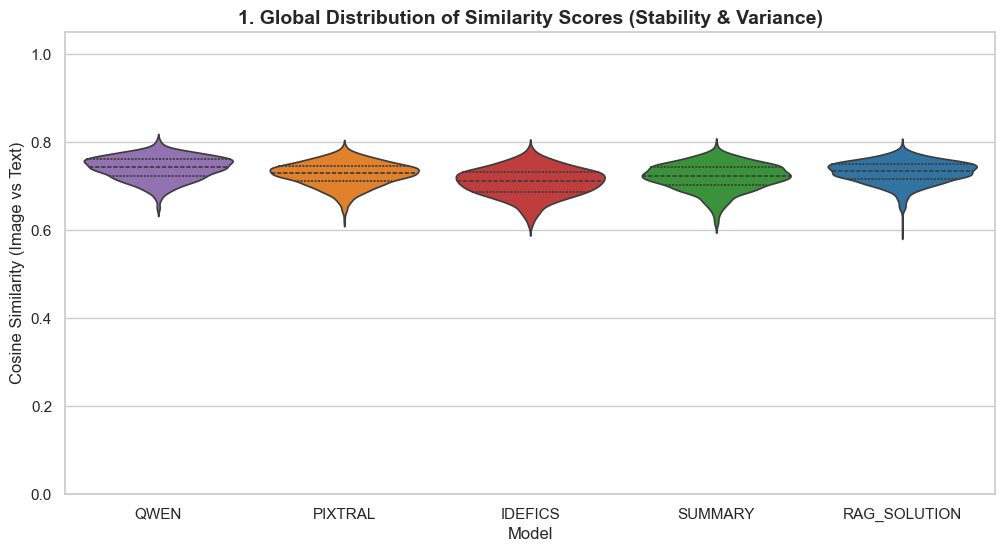

C:\Users\cam20\AppData\Local\Temp\ipykernel_28560\8636302.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_usability, x="High-Quality Rate (%)", y="Model", palette=[MODEL_COLORS.get(f"{m.lower()}_score", "#333") for m in df_usability["Model"]])


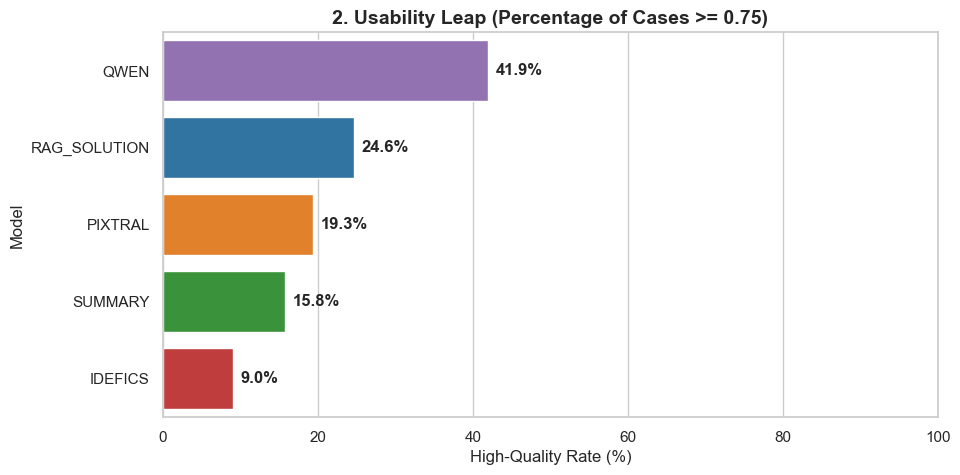

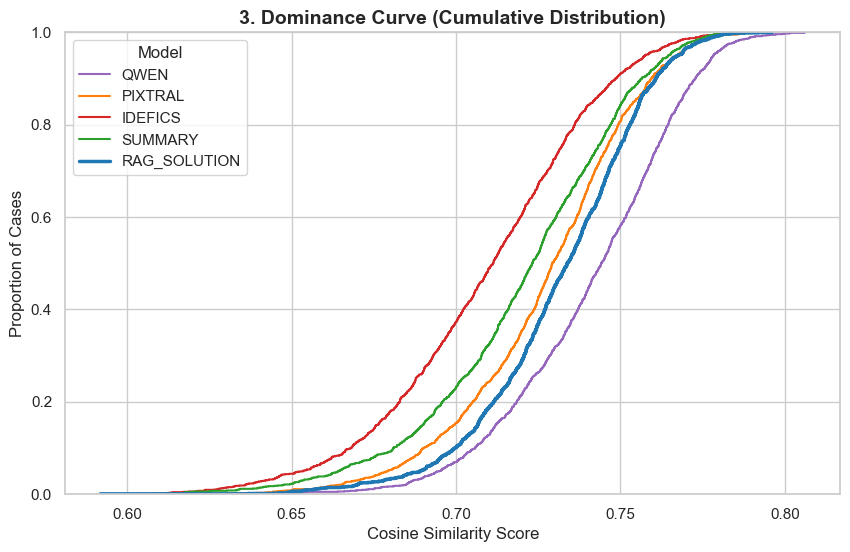

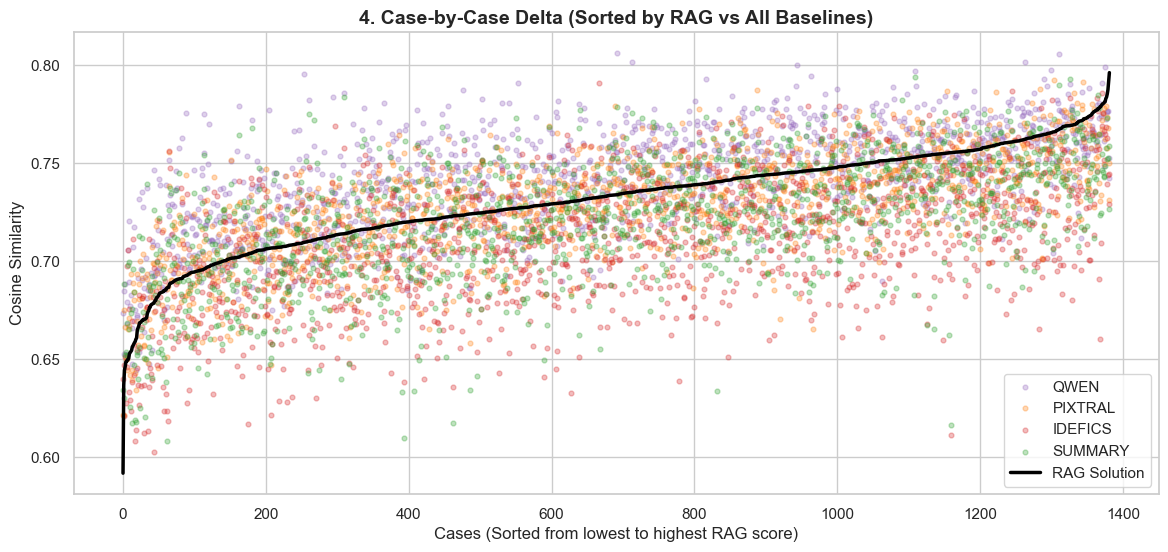

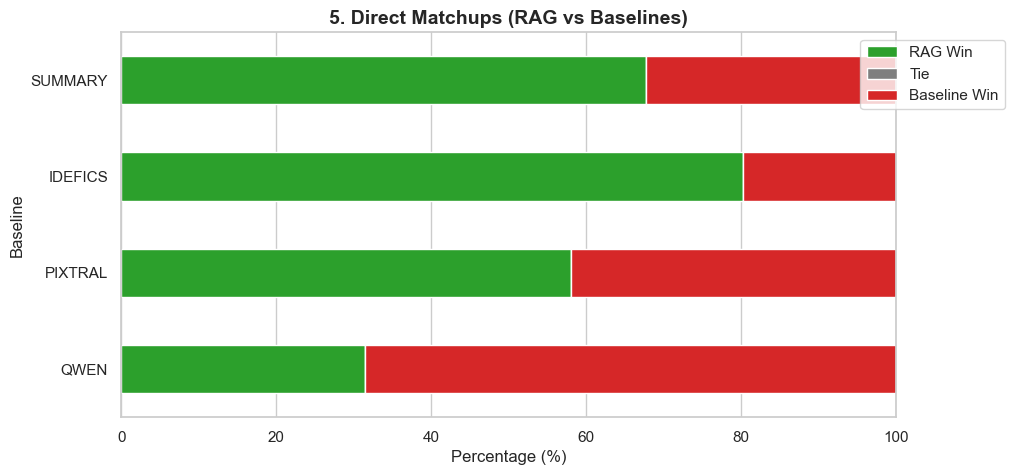

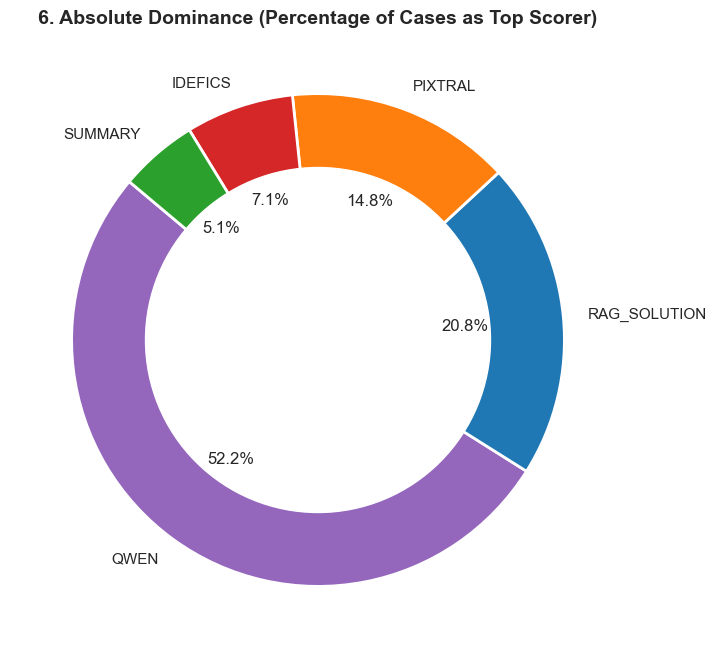

In [22]:
# Plotting Configuration
sns.set_theme(style="whitegrid")
# Standardized colors for models: RAG (Blue), Summary (Green), Qwen (Purple), Pixtral (Orange), Idefics (Red), 
MODEL_COLORS = {
    "rag_solution_score": "#1f77b4", 
    "summary_score": "#2ca02c",
    "qwen_score": "#9467bd",
    "pixtral_score": "#ff7f0e", 
    "idefics_score": "#d62728"
}
LABELS = {f"{m}_score": m.upper() for m in MODELS}

# Create a melted dataframe for seaborn
df_melted = df_scores.melt(value_vars=[f"{m}_score" for m in MODELS], var_name="Model", value_name="Cosine Similarity")
df_melted["Model"] = df_melted["Model"].map(LABELS)

# 1. GLOBAL DISTRIBUTION: VIOLIN PLOT (Seaborn)
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_melted, x="Model", y="Cosine Similarity", inner="quartile", palette=[MODEL_COLORS[m] for m in [f"{mod}_score" for mod in MODELS]])
plt.title("1. Global Distribution of Similarity Scores (Stability & Variance)", fontsize=14, fontweight='bold')
plt.ylabel("Cosine Similarity (Image vs Text)")
plt.ylim(0, 1.05)
plt.show()

# 2. USABILITY LEAP: HORIZONTAL BAR CHART (Seaborn)
usability_rates = {}
# We must recalculathe the usability rates since they were merged into the comparative table from the previous step
for m in MODELS:
    col = f"{m}_score"
    valid = df_scores[col].dropna()
    pass_rate = (valid >= USABILITY_THRESHOLD).sum() / len(valid) * 100 if len(valid) > 0 else 0
    usability_rates[LABELS[col]] = pass_rate
df_usability = pd.DataFrame(list(usability_rates.items()), columns=["Model", "High-Quality Rate (%)"])
df_usability = df_usability.sort_values(by="High-Quality Rate (%)", ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_usability, x="High-Quality Rate (%)", y="Model", palette=[MODEL_COLORS.get(f"{m.lower()}_score", "#333") for m in df_usability["Model"]])
plt.title(f"2. Usability Leap (Percentage of Cases >= {USABILITY_THRESHOLD})", fontsize=14, fontweight='bold')
plt.xlabel("High-Quality Rate (%)")
plt.xlim(0, 100)
# Add percentage text to the bars
for i, v in enumerate(df_usability["High-Quality Rate (%)"]):
    plt.text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold')
plt.show()

# 3. STRICT DOMINANCE: CUMULATIVE DISTRIBUTION FUNCTION - CDF (Seaborn)
plt.figure(figsize=(10, 6))
for m in MODELS:
    col = f"{m}_score"
    sns.ecdfplot(data=df_scores, x=col, label=LABELS[col], color=MODEL_COLORS[col], linewidth=2.5 if m=="rag_solution" else 1.5)
plt.title("3. Dominance Curve (Cumulative Distribution)", fontsize=14, fontweight='bold')
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Proportion of Cases")
plt.legend(title="Model")
plt.show()

# 4. CASE-BY-CASE DELTA: SORTED PERFORMANCE CURVE - Comparing RAG vs all baselines (Matplotlib)
# Sort by the RAG score so it forms a clean line
df_sorted = df_scores.dropna(subset=["rag_solution_score"]).sort_values(by="rag_solution_score").reset_index(drop=True)
plt.figure(figsize=(14, 6))
# Plot the 4 Baselines as semi-transparent dots first (so they sit in the background)
baselines = [m for m in MODELS if m != "rag_solution"]
for base in baselines:
    base_col = f"{base}_score"
    plt.scatter(df_sorted.index, df_sorted[base_col], label=LABELS[base_col], color=MODEL_COLORS[base_col], alpha=0.3, s=12)
# Plot the RAG system as a thick black line on top of the dot cloud
plt.plot(df_sorted.index, df_sorted["rag_solution_score"], label="RAG Solution", color="black", linewidth=2.5)
plt.title("4. Case-by-Case Delta (Sorted by RAG vs All Baselines)", fontsize=14, fontweight='bold')
plt.xlabel("Cases (Sorted from lowest to highest RAG score)")
plt.ylabel("Cosine Similarity")
plt.legend(loc='lower right')
plt.show()

# 5. DIRECT MATCHUPS: WIN/LOSS STACKED BAR CHART
matchup_data = []
for base in baselines:
    base_col = f"{base}_score"
    rag_col = "rag_solution_score"
    valid = df_scores.dropna(subset=[base_col, rag_col])
    total = len(valid)
    wins = (valid[rag_col] > valid[base_col]).sum() / total * 100
    losses = (valid[rag_col] < valid[base_col]).sum() / total * 100
    ties = (valid[rag_col] == valid[base_col]).sum() / total * 100
    matchup_data.append([LABELS[base_col], wins, ties, losses])
df_matchup = pd.DataFrame(matchup_data, columns=["Baseline", "RAG Win", "Tie", "Baseline Win"])
df_matchup.set_index("Baseline").plot(kind="barh", stacked=True, color=["#2ca02c", "#7f7f7f", "#d62728"], figsize=(10, 5))
plt.title("5. Direct Matchups (RAG vs Baselines)", fontsize=14, fontweight='bold')
plt.xlabel("Percentage (%)")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xlim(0, 100)
plt.show()

# 6. OVERALL DOMINANCE: BEST MODEL RATE (Donut Chart)
plt.figure(figsize=(8, 8))
# Get the counts of how many times each model won
best_counts = df_scores[[f"{m}_score" for m in MODELS]].idxmax(axis=1).value_counts()
# Map the index to the labels and colors
pie_labels = [LABELS[col] for col in best_counts.index]
pie_colors = [MODEL_COLORS[col] for col in best_counts.index]
# Create the base pie chart
plt.pie(best_counts, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
# Draw a white circle in the center to turn it into a Donut Chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("6. Absolute Dominance (Percentage of Cases as Top Scorer)", fontsize=14, fontweight='bold')
plt.show()

## Section 3: Stratified Analysis

In this section, we will dive into an even deeper anlysis breaking down the performance of the models into certain columns from the metadata of our seed case base, because global metrics can hide specific aspects or trends of the internal system. The mathematical aggregation scores will be separated across the following columns:
1. **Visual Taxonomy:** By `library` and `xai_graph_type`.
2. **Comparable Graphs Families:** By `analytical_family`.
3. **Task Complexity:** By `scope` (Local vs. Global) and `ai_problem_type` (Classification vs. Regression).

Using these combinations we plot relevant comparison graphs to illustrate the obtained results.

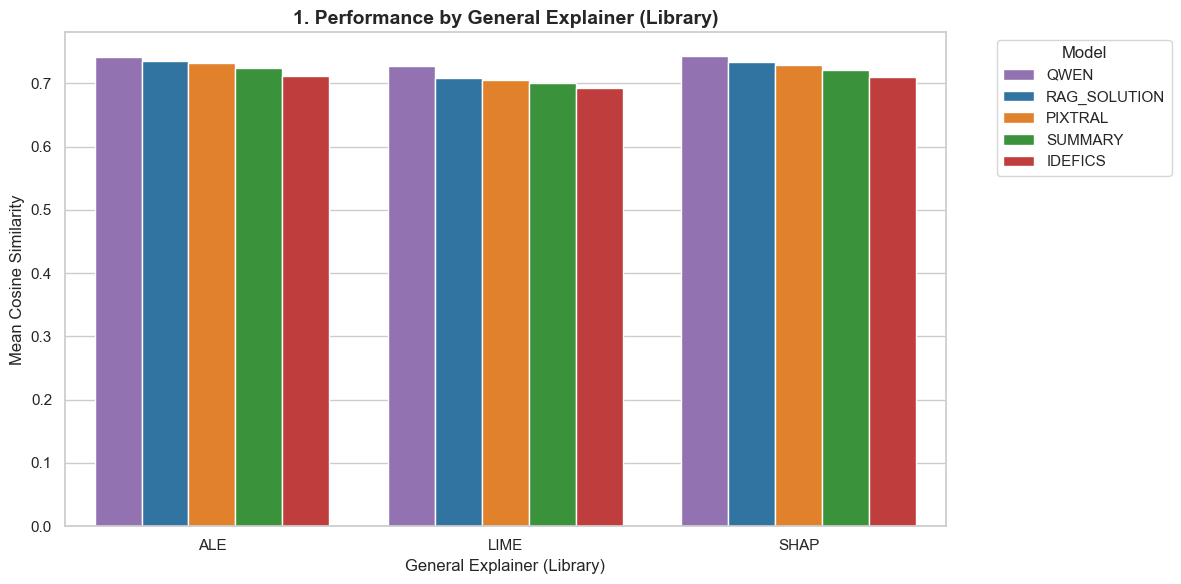

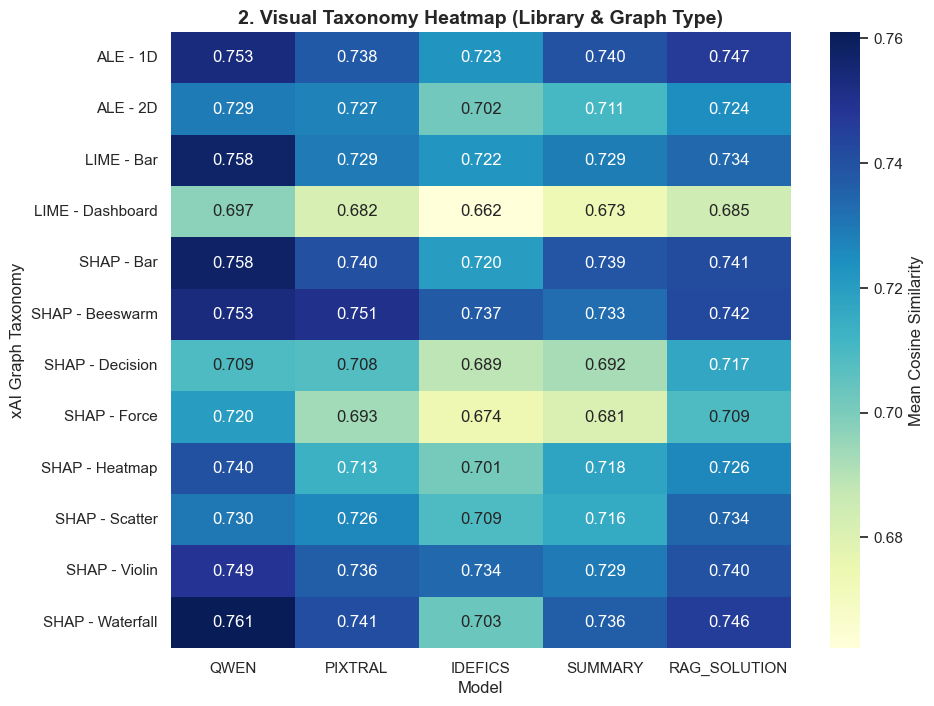

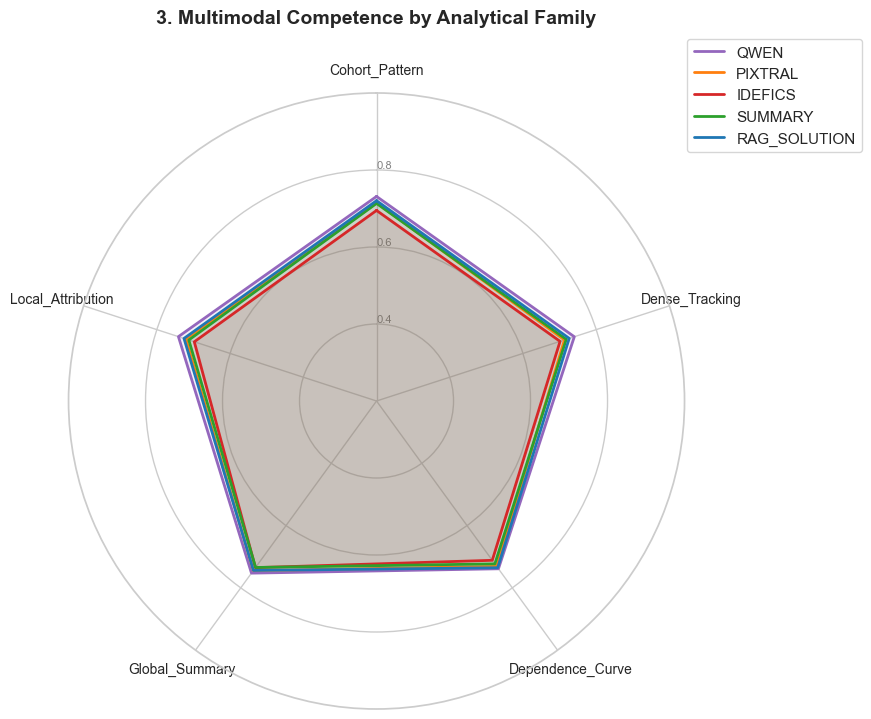

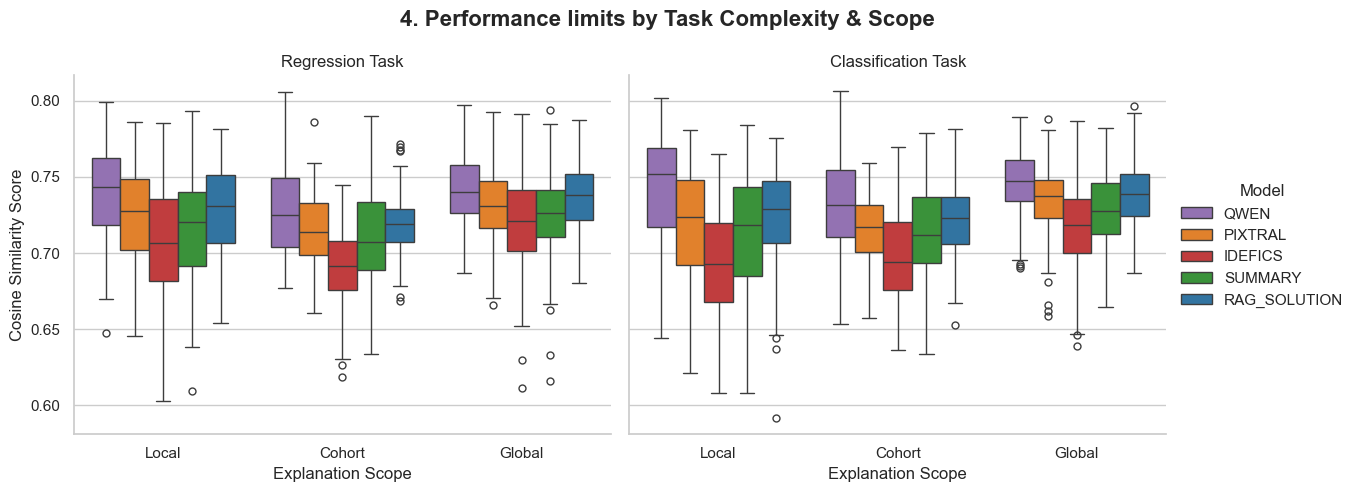

In [23]:
import math

# 1. PERFORMANCE BY LIBRARY (Grouped Bar Chart)
# Group the data by library and calculate means
df_library = df_scores.groupby('library')[[f"{m}_score" for m in MODELS]].mean().reset_index()
# Melt it for Seaborn
df_lib_melted = df_library.melt(id_vars='library', var_name="Model", value_name="Score")
df_lib_melted["Model"] = df_lib_melted["Model"].map(LABELS)
# Calculate the overall global mean to determine the fixed best-to-worst order
fixed_order = df_lib_melted.groupby('Model')['Score'].mean().sort_values(ascending=False).index.tolist()
# Create a dictionary mapping the specific labels to their exact colors
mapped_colors = {LABELS[f"{m}_score"]: MODEL_COLORS[f"{m}_score"] for m in MODELS}
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_lib_melted, 
    x='library', 
    y='Score', 
    hue='Model', 
    hue_order=fixed_order, # Forces the bars and legend to match the global ranking
    palette=mapped_colors  # Locks the colors safely using the dictionary
)
plt.title("1. Performance by General Explainer (Library)", fontsize=14, fontweight='bold')
plt.ylabel("Mean Cosine Similarity")
plt.xlabel("General Explainer (Library)")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the legend doesn't get cut off
plt.show()

# 2. TAXONOMY HEATMAP (Library + Graph Type) 
# Create a new column combining library and graph type
df_scores['Taxonomy'] = df_scores['library'] + " - " + df_scores['xai_graph_type']
# Group by Taxonomy and calculate mean for each model
df_taxonomy = df_scores.groupby('Taxonomy')[[f"{m}_score" for m in MODELS]].mean()
df_taxonomy.columns = [LABELS[c] for c in df_taxonomy.columns]
plt.figure(figsize=(10, 8))
sns.heatmap(df_taxonomy, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Mean Cosine Similarity'})
plt.title("2. Visual Taxonomy Heatmap (Library & Graph Type)", fontsize=14, fontweight='bold')
plt.ylabel("xAI Graph Taxonomy")
plt.xlabel("Model")
plt.show()

# 3. COMPETENCE RADAR CHART (Analytical Family)
df_family = df_scores.groupby('analytical_family')[[f"{m}_score" for m in MODELS]].mean()
categories = df_family.index.tolist()
N = len(categories)
# Calculate angles for the radar chart
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=10)
ax.set_rlabel_position(0)
plt.yticks([0.4, 0.6, 0.8], ["0.4", "0.6", "0.8"], color="grey", size=8)
plt.ylim(0.2, 1.0)
# Plot each model
for m in MODELS:
    col = f"{m}_score"
    values = df_family[col].tolist()
    values += values[:1] # Close the circle
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=LABELS[col], color=MODEL_COLORS[col])
    ax.fill(angles, values, color=MODEL_COLORS[col], alpha=0.1)
plt.title("3. Multimodal Competence by Analytical Family", size=14, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


# 4. TASK COMPLEXITY: GROUPED BOX PLOTS (Scope & Problem Type)
# Melt the data keeping scope and problem type
df_complex = df_scores.melt(id_vars=['ai_problem_type', 'scope'], value_vars=[f"{m}_score" for m in MODELS], var_name="Model", value_name="Score")
df_complex["Model"] = df_complex["Model"].map(LABELS)
# Create a FacetGrid to plot Problem Type (Cols) and Scope (Rows/Hues)
g = sns.catplot(data=df_complex, x="scope", y="Score", hue="Model", col="ai_problem_type", kind="box", palette=[MODEL_COLORS[f"{m.lower()}_score"] for m in LABELS.values()], height=5, aspect=1.2)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("4. Performance limits by Task Complexity & Scope", fontsize=16, fontweight='bold')
g.set_axis_labels("Explanation Scope", "Cosine Similarity Score")
g.set_titles("{col_name} Task")
plt.show()